In [1]:
!wget -nc https://zenodo.org/record/7041849/files/PapalexiSatija2021_eccite_RNA.h5ad
!wget -nc https://zenodo.org/record/7041849/files/PapalexiSatija2021_eccite_protein.h5ad
!pip install pyro-ppl graphviz seaborn anndata

File ‘PapalexiSatija2021_eccite_RNA.h5ad’ already there; not retrieving.

File ‘PapalexiSatija2021_eccite_protein.h5ad’ already there; not retrieving.


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import multiprocessing

multiprocessing.cpu_count()

10

In [3]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd
import seaborn as sns
import pyro
import pyro.distributions as dist
from pyro.infer import (
    SVI,
    TraceEnum_ELBO,
    Trace_ELBO,
    TraceMeanField_ELBO,
    JitTraceEnum_ELBO,
    config_enumerate,
    infer_discrete,
)

from torch.utils.data import (
    Dataset,
    Sampler,
    DataLoader,
    WeightedRandomSampler,
    SubsetRandomSampler,
    BatchSampler,
)

from pyro.optim import Adam, ClippedAdam
from pyro.ops.indexing import Vindex

from pyro import poutine, render_model
from pyro.infer.autoguide import AutoNormal, AutoDelta, init_to_median, init_to_value
import sys
from tqdm import tqdm

if torch.cuda.is_available():
    print("Let's ride")
    device = "cuda"
    torch.set_float32_matmul_precision("high")
    # torch.set_default_device("cuda")
    smoke_test = False
else:
    device = "cpu"
    smoke_test = True
smoke_test = False


In [4]:
adata = ad.read_h5ad("PapalexiSatija2021_eccite_RNA.h5ad")
adata

AnnData object with n_obs × n_vars = 20729 × 18649
    obs: 'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [5]:
prot_adata = ad.read_h5ad("PapalexiSatija2021_eccite_protein.h5ad")
prot_adata.var_names = prot_adata.var_names + "_protein"

In [6]:
prot_df = prot_adata.to_df().join(prot_adata.obs)
prot_df


,CD86_protein,PDL1_protein,PDL2_protein,CD366_protein,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,...,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo
AAACCTGAGCCAGAAC,118.0,522.0,94.0,67.0,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,801.0,0.0,0.0
AAACCTGAGTGGACGT,243.0,139.0,104.0,59.0,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,545.0,0.0,0.0
AAACCTGCATGAGCGA,99.0,109.0,56.0,80.0,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,344.0,0.0,0.0
AAACCTGTCTTGTCAT,110.0,334.0,48.0,47.0,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,539.0,0.0,0.0
AAACGGGAGAACAACT,303.0,593.0,77.0,80.0,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,1053.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,98.0,151.0,135.0,14.0,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,398.0,0.0,0.0
TTTGTCAGTGACGGTA,1781.0,1117.0,89.0,55.0,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,0,4,3042.0,0.0,0.0
TTTGTCAGTTCCACAA,84.0,73.0,38.0,17.0,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,212.0,0.0,0.0
TTTGTCATCACGCATA,18.0,135.0,37.0,68.0,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,258.0,0.0,0.0


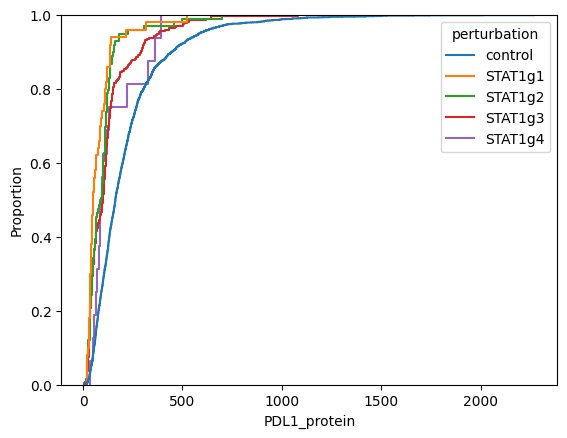

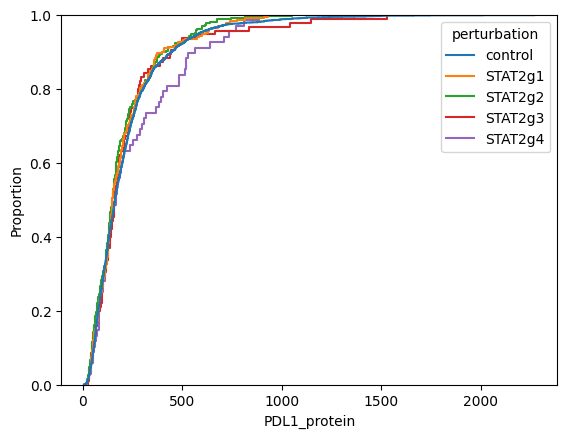

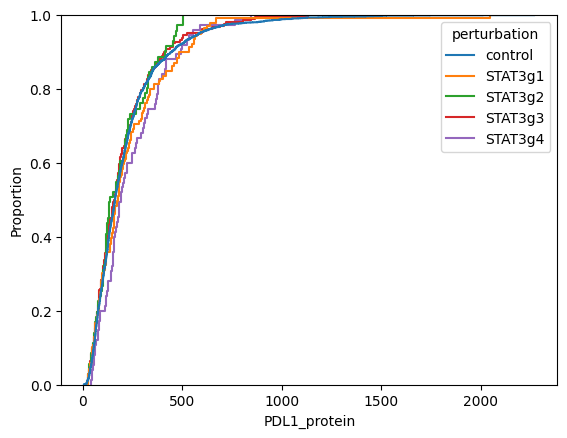

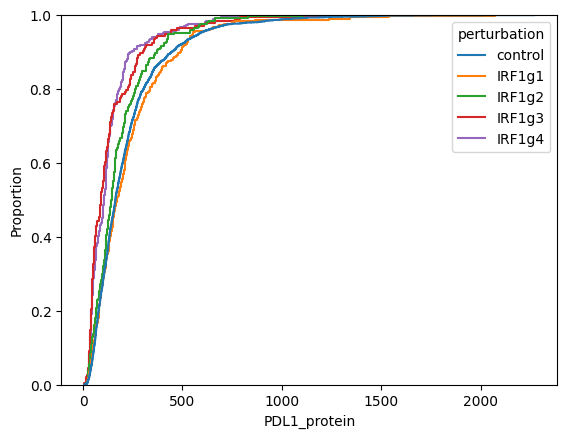

In [7]:
for plot_gene in ["STAT1", "STAT2", "STAT3", "IRF1"]:
    sns.ecdfplot(prot_df, hue="perturbation", x="PDL1_protein", hue_order=["control"]+[f"{plot_gene}g{i}" for i in range(1,5)])
    plt.show()

In [8]:
adata.obs

,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,cell_line,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo
AAACCTGAGCCAGAAC,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3942,17207.0,2.295577,14.714942
AAACCTGAGTGGACGT,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2948,9506.0,4.512939,9.877972
AAACCTGCATGAGCGA,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4258,15256.0,4.116413,13.227583
AAACCTGTCTTGTCAT,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,1780,5135.0,5.491723,21.888997
AAACGGGAGAACAACT,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2671,9673.0,3.359868,13.263724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4884,20863.0,5.469012,13.914586
TTTGTCAGTGACGGTA,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,0,3787,17553.0,2.159175,7.673902
TTTGTCAGTTCCACAA,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4185,15106.0,2.661194,14.338673
TTTGTCATCACGCATA,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3204,11209.0,7.369078,10.036578


In [9]:
n_mito = adata[:, adata.var_names.str.startswith("MT-")].X.sum(axis=1).A1
n_rps = adata[:, adata.var_names.str.match("RPS[0-9]+")].X.sum(axis=1).A1
n_rpl = adata[:, adata.var_names.str.match("RPL[0-9]+")].X.sum(axis=1).A1
n_ribo = n_rps + n_rpl
n_total = adata.X.sum(axis=1).A1
# adata.obs
# plt.scatter(n_total, n_ribo, alpha=0.1)
# plt.scatter(n_total, n_mito, alpha=0.1)
# plt.scatter(n_ribo, n_mito, alpha=0.1)

In [10]:
adata.obs = adata.obs.assign(
    element=lambda x: x["perturbation"].str.replace("g[0-9]+$", "", regex=True)
)
adata.obs["element"]

AAACCTGAGCCAGAAC      STAT2
AAACCTGAGTGGACGT       CAV1
AAACCTGCATGAGCGA      STAT1
AAACCTGTCTTGTCAT       CD86
AAACGGGAGAACAACT       IRF7
                     ...   
TTTGTCAGTCACTTCC      CMTM6
TTTGTCAGTGACGGTA    control
TTTGTCAGTTCCACAA       ATF2
TTTGTCATCACGCATA       CAV1
TTTGTCATCTGTACGA      STAT3
Name: element, Length: 20729, dtype: object

In [11]:
# pick a subset of random genes including 3 known ones
# stat_target_genes = ["STAT1", "STAT2", "IRF1"]

# pick a subset of 50 genes including all perturbed ones

if smoke_test:
    n_genes_subset = 50
    target_genes = [e for e in adata.obs["element"].unique() if e != "control"]
    # target_genes += prot_adata.var_names.tolist()
    other_genes = [gene for gene in adata.var_names if gene not in target_genes]
    selected_genes = target_genes + other_genes[: n_genes_subset - len(target_genes)]
    # selected_genes = stat_target_genes + list(
    #     np.random.choice(other_genes, size=n_genes_subset - len(stat_target_genes))
    # )

    # selected_guides = [f"STAT1g{i}" for i in range(1, 5)] + ["control"]
    # guide_filter = adata.obs["perturbation"].isin(selected_guides)
    # adata_subset = adata[guide_filter, :][:, selected_genes]
    adata_subset = adata[:, selected_genes]

else:
    min_counts = 100 # min no. of cells with at least 1 count
    selected_genes = ((adata.X>0).sum(axis=0)) > min_counts
    adata_subset = adata[:, selected_genes]
adata_subset

View of AnnData object with n_obs × n_vars = 20729 × 50
    obs: 'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'element'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [12]:
adata_subset.var_names

Index(['STAT2', 'CAV1', 'STAT1', 'CD86', 'IRF7', 'ATF2', 'STAT3', 'JAK2',
       'NFKBIA', 'SMAD4', 'STAT5A', 'CMTM6', 'IFNGR1', 'UBE2L6', 'PDCD1LG2',
       'CUL3', 'BRD4', 'MARCH8', 'IRF1', 'POU2F2', 'ETV7', 'IFNGR2',
       'TNFRSF14', 'SPI1', 'MYC', 'AL627309.1', 'AP006222.2', 'RP4-669L17.10',
       'RP11-206L10.3', 'RP11-206L10.2', 'RP11-206L10.9', 'LINC00115',
       'FAM41C', 'SAMD11', 'NOC2L', 'KLHL17', 'PLEKHN1', 'HES4', 'ISG15',
       'AGRN', 'RP11-54O7.18', 'C1orf159', 'TNFRSF18', 'TNFRSF4', 'SDF4',
       'B3GALT6', 'FAM132A', 'RP5-902P8.12', 'UBE2J2', 'SCNN1D'],
      dtype='object', name='gene_symbol')

In [13]:
# from siphon.module import train
import mudata as md
grna_observed = pd.get_dummies(adata_subset.obs["guide_id"]).astype(int)

In [14]:
guide_by_element = (
    pd.crosstab(adata_subset.obs["guide_id"], adata_subset.obs["element"])
    .reindex(index=grna_observed.columns)
    > 0
).astype(int)

guide_by_element = guide_by_element.iloc[:,:-1] # remove control
guide_by_element

element,ATF2,BRD4,CAV1,CD86,CMTM6,CUL3,ETV7,IFNGR1,IFNGR2,IRF1,...,PDCD1LG2,POU2F2,SMAD4,SPI1,STAT1,STAT2,STAT3,STAT5A,TNFRSF14,UBE2L6
ATF2g1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ATF2g2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ATF2g3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ATF2g4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BRD4g1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TNFRSF14g4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
UBE2L6g1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
UBE2L6g2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
UBE2L6g3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [15]:
n_elements = guide_by_element.shape[1]
gene_by_element = (
    pd.DataFrame(np.eye(n_elements), index=guide_by_element.columns, columns=guide_by_element.columns)
    .reindex(index=adata_subset.var_names)
    .fillna(0)
)
adata_subset.varm["element_targets"] = gene_by_element
adata_subset.varm["element_targets"]

/var/folders/w9/llll0v7j02zdytwd43sshysm0000gp/T/ipykernel_17357/1485371578.py:7: ImplicitModificationWarning: Setting element `.varm['element_targets']` of view, initializing view as actual.
  adata_subset.varm["element_targets"] = gene_by_element


element,ATF2,BRD4,CAV1,CD86,CMTM6,CUL3,ETV7,IFNGR1,IFNGR2,IRF1,...,PDCD1LG2,POU2F2,SMAD4,SPI1,STAT1,STAT2,STAT3,STAT5A,TNFRSF14,UBE2L6
gene_symbol,,,,,,,,,,,,,,,,,,,,,
STAT2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
CAV1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
STAT1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
CD86,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
IRF7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ATF2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
STAT3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
JAK2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NFKBIA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
gdata = ad.AnnData(grna_observed, varm={"guide_targets": guide_by_element})
mdata = md.MuData({"rna":adata_subset, "grna":gdata})
mdata

MuData object with n_obs × n_vars = 20729 × 157
  2 modalities
    rna:	20729 x 50
      obs:	'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'element'
      var:	'ensembl_id', 'ncounts', 'ncells'
      varm:	'element_targets'
    grna:	20729 x 107
      varm:	'guide_targets'

In [17]:
mdata["rna"].obs

,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,cell_line,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo,element
AAACCTGAGCCAGAAC,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3942,17207.0,2.295577,14.714942,STAT2
AAACCTGAGTGGACGT,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2948,9506.0,4.512939,9.877972,CAV1
AAACCTGCATGAGCGA,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4258,15256.0,4.116413,13.227583,STAT1
AAACCTGTCTTGTCAT,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,1780,5135.0,5.491723,21.888997,CD86
AAACGGGAGAACAACT,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2671,9673.0,3.359868,13.263724,IRF7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4884,20863.0,5.469012,13.914586,CMTM6
TTTGTCAGTGACGGTA,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,0,3787,17553.0,2.159175,7.673902,control
TTTGTCAGTTCCACAA,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4185,15106.0,2.661194,14.338673,ATF2
TTTGTCATCACGCATA,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3204,11209.0,7.369078,10.036578,CAV1


In [18]:
import perturbo
perturbo.PERTURBO.setup_mudata(
    mdata,
    batch_key="hto",
    library_size_key="ncounts",
    continuous_covariates_keys=["percent_mito", "percent_ribo"],
    guide_by_element_key="guide_targets",
    gene_by_element_key="element_targets",
    modalities={
        "rna_layer": "rna",
        "perturbation_layer": "grna",
    },
)

model = perturbo.PERTURBO(mdata, likelihood="nb", efficiency_mode="mixture", n_factors=5, n_pert_factors=20)
# model = perturbo.PERTURBO(mdata, likelihood="nb", efficiency_mode="mixture", n_factors=5, n_pert_factors=20)
# model = perturbo.PERTURBO(mdata, likelihood="nb", efficiency_mode="scaled", n_factors=5, n_pert_factors=10)

model.view_anndata_setup()


/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


INFO     Using column names from columns of adata.varm['element_targets']                                          
INFO     Using column names from columns of adata.varm['guide_targets']                                            


<frozen abc>:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

<frozen abc>:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:101: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self

Anndata setup with scvi-tools version 1.0.4.

Setup via `PERTURBO.setup_anndata` with arguments:

...

        Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃    Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch         │   5   │
│         n_cells         │ 20729 │
│ n_extra_continuous_covs │   2   │
│  n_gene_summary_stats   │   1   │
│     n_perturbations     │  107  │
│   n_targeted_elements   │  25   │
│    n_tested_elements    │  25   │
│         n_vars          │  50   │
└─────────────────────────┴───────┘

                                 Data Registry                                  
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Registry Key      ┃                 scvi-tools Location                  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X           │                  adata.mod['rna'].X                  │
│         batch         │         adata.mod['rna'].obs['_scvi_batch']          │
│ extra_continuous_covs │ adata.mod['rna'].obsm['_scvi_extra_continuous_covs'] │
│  gene_summary_stats   │  adata.mod['rna'].varm['_scvi_gene_summary_stats']   │
│         ind_x         │            adata.mod['rna'].obs['_ind_x']            │
│     perturbations     │                 adata.mod['grna'].X                  │
│      size_factor      │         adata.mod['rna'].obs['_size_factor']         │
│   targeted_elements   │       adata.mod['grna'].varm['guide_targets']        │
│    tested_elements    │       adata.mod['rna'].varm['element_targets']       │
└───────────────────────┴──────────────────────────────────────────────────────┘

                 batch State Registry                  
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Source Location  ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['hto'] │  rep1-tx   │          0          │
│                  │ rep2-ctrl  │          1          │
│                  │  rep2-tx   │          2          │
│                  │  rep3-tx   │          3          │
│                  │  rep4-tx   │          4          │
└──────────────────┴────────────┴─────────────────────┘

 gene_summary_stats State  
         Registry          
┏━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location     ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.var['_gene_mean'] │
└─────────────────────────┘

 extra_continuous_covs State 
          Registry           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['percent_mito'] │
│ adata.obs['percent_ribo'] │
└───────────────────────────┘

In [19]:
model.train(
    200,
    lr=0.01,
    batch_size=512,
    # callbacks=[checkpoint_callback],
    # enable_checkpointing=True,
    early_stopping=True,
    early_stopping_patience=10,
    early_stopping_min_delta=1e-2,
    early_stopping_monitor="elbo_train",
)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/lightning/pytorch/trainer/configuration_validator.py:69: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")


Epoch 28/200:  14%|█▎        | 27/200 [00:25<02:47,  1.03it/s, v_num=1, elbo_train=1.09e+6]

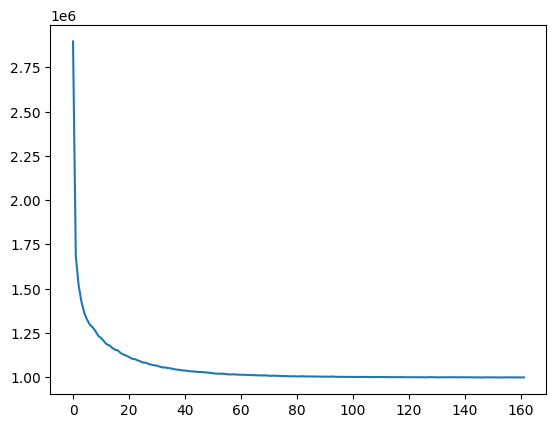

In [20]:
plt.plot(model.history["elbo_train"])

In [21]:
model.module.guide.median().keys()

dict_keys(['guide_efficacy', 'pert_factors', 'pert_loadings', 'cell_factors', 'cell_loadings', 'log_gene_mean', 'log_gene_dispersion', 'batch_effect', 'cont_covariate_effect', 'element_effects'])

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


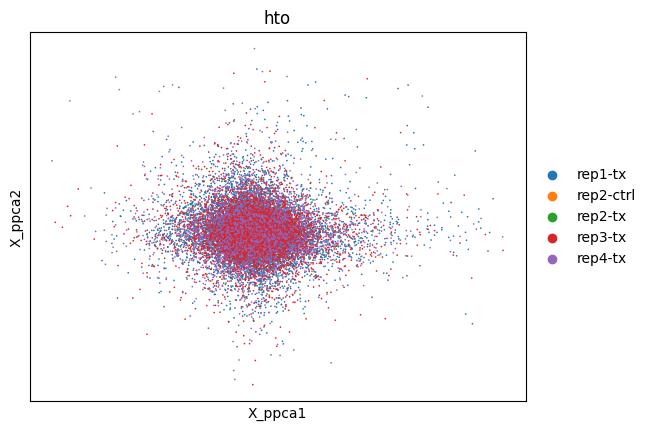

In [23]:
import scanpy as sc
# pyro.get_param_store["cell_factors"].shape
if "cell_factors" in model.module.guide.median():
    cell_factors = model.module.guide.median()["cell_factors"].squeeze().T.numpy()
    # cell_factors = pyro.get_param_store()["AutoGuideList.1.cell_factors"].detach().squeeze().T.numpy()
    mdata["rna"].obsm["X_ppca"] = cell_factors
    sc.pl.embedding(mdata["rna"], basis="X_ppca", color="hto")

In [50]:
if "cell_loadings" in model.module.guide.median():
    loadings_df = pd.DataFrame(model.module.guide.median()["cell_loadings"].squeeze(), columns=mdata["rna"].var_names)
    print(loadings_df)

gene_symbol     STAT2      CAV1     STAT1      CD86      IRF7      ATF2  \
0           -0.160659  0.309874 -0.068706  0.089107 -0.071704  0.024451   
1           -0.030722  0.067029 -0.028444 -0.138143  0.022422  0.115976   
2            0.081590  0.048608  0.027672  0.488960  0.037660 -0.059636   
3            0.029346 -0.017098  0.087777 -0.030682  0.229231  0.085022   
4            0.192549  0.257093  0.053113  0.205935  0.036730  0.197739   

gene_symbol     STAT3      JAK2    NFKBIA     SMAD4  ...  RP11-54O7.18  \
0           -0.020292 -0.129595  0.172363 -0.072480  ...      0.075537   
1           -0.043278 -0.096702 -0.065082 -0.174779  ...      0.031345   
2           -0.015462  0.061175  0.181057 -0.003451  ...      0.379177   
3            0.129418  0.096047  0.319706  0.001038  ...      0.016287   
4            0.038814  0.043866 -0.105793  0.107849  ...     -0.143673   

gene_symbol  C1orf159  TNFRSF18   TNFRSF4      SDF4   B3GALT6   FAM132A  \
0           -0.085188  0.7184

In [25]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)


AutoGuideList.0.locs.guide_efficacy torch.Size([107, 1])
AutoGuideList.0.scales.guide_efficacy torch.Size([107, 1])
AutoGuideList.0.locs.pert_factors torch.Size([20, 25, 1])
AutoGuideList.0.scales.pert_factors torch.Size([20, 25, 1])
AutoGuideList.0.locs.pert_loadings torch.Size([20, 1, 50])
AutoGuideList.0.scales.pert_loadings torch.Size([20, 1, 50])
AutoGuideList.0.locs.cell_factors torch.Size([5, 20729, 1])
AutoGuideList.0.scales.cell_factors torch.Size([5, 20729, 1])
AutoGuideList.0.locs.cell_loadings torch.Size([5, 1, 50])
AutoGuideList.0.scales.cell_loadings torch.Size([5, 1, 50])
AutoGuideList.0.locs.log_gene_mean torch.Size([50])
AutoGuideList.0.scales.log_gene_mean torch.Size([50])
AutoGuideList.0.locs.log_gene_dispersion torch.Size([50])
AutoGuideList.0.scales.log_gene_dispersion torch.Size([50])
AutoGuideList.0.locs.batch_effect torch.Size([5, 50])
AutoGuideList.0.scales.batch_effect torch.Size([5, 50])
AutoGuideList.0.locs.cont_covariate_effect torch.Size([3, 50])
AutoGuide

In [26]:
# plt.scatter(siphon_model.dataset.size_factor, siphon_model.guide.median()["size_factor_fit"], alpha=0.01)

In [27]:
# plt.plot(losses)

In [28]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)

AutoGuideList.0.locs.guide_efficacy torch.Size([107, 1])
AutoGuideList.0.scales.guide_efficacy torch.Size([107, 1])
AutoGuideList.0.locs.pert_factors torch.Size([20, 25, 1])
AutoGuideList.0.scales.pert_factors torch.Size([20, 25, 1])
AutoGuideList.0.locs.pert_loadings torch.Size([20, 1, 50])
AutoGuideList.0.scales.pert_loadings torch.Size([20, 1, 50])
AutoGuideList.0.locs.cell_factors torch.Size([5, 20729, 1])
AutoGuideList.0.scales.cell_factors torch.Size([5, 20729, 1])
AutoGuideList.0.locs.cell_loadings torch.Size([5, 1, 50])
AutoGuideList.0.scales.cell_loadings torch.Size([5, 1, 50])
AutoGuideList.0.locs.log_gene_mean torch.Size([50])
AutoGuideList.0.scales.log_gene_mean torch.Size([50])
AutoGuideList.0.locs.log_gene_dispersion torch.Size([50])
AutoGuideList.0.scales.log_gene_dispersion torch.Size([50])
AutoGuideList.0.locs.batch_effect torch.Size([5, 50])
AutoGuideList.0.scales.batch_effect torch.Size([5, 50])
AutoGuideList.0.locs.cont_covariate_effect torch.Size([3, 50])
AutoGuide

In [29]:
guide=model.module.guide
guides = mdata["grna"].var_names
elements = guide_by_element.index
guide.median().keys()

dict_keys(['guide_efficacy', 'pert_factors', 'pert_loadings', 'cell_factors', 'cell_loadings', 'log_gene_mean', 'log_gene_dispersion', 'batch_effect', 'cont_covariate_effect', 'element_effects'])

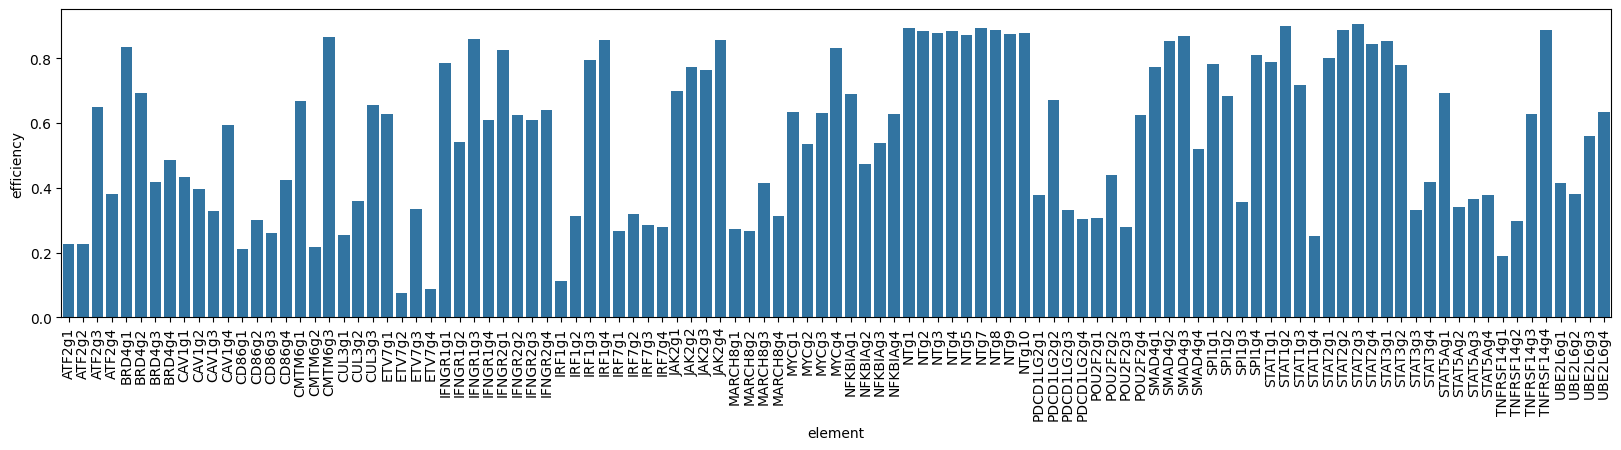

In [30]:
guides = guide_by_element.index
elements = guide_by_element.columns
plt.figure(figsize=(20, 4))
if "guide_efficacy" in guide.median():
    element_efficiency = pd.DataFrame(
        guide.median()["guide_efficacy"].detach().cpu(),
        index=guides,
        columns=["efficiency"],
    ).reset_index(names="element")
    element_efficiency
    sns.barplot(element_efficiency, x="element", y="efficiency")
    plt.xticks(rotation=90)

array([[<Axes: title={'center': 'efficiency'}>]], dtype=object)

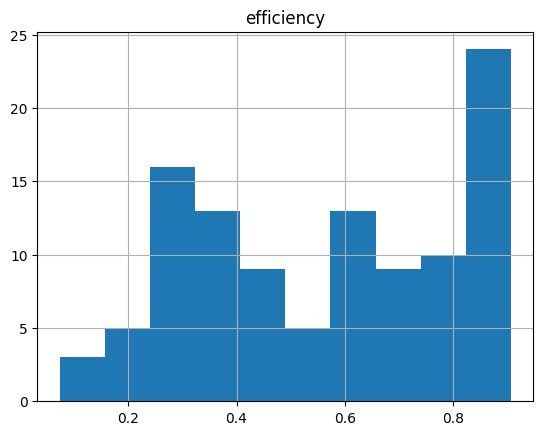

In [31]:
median_efficiency = pd.DataFrame(
    guide.median()["guide_efficacy"].detach().cpu(),
    index=guides,
    columns=["efficiency"],
).assign(
    guide=lambda x: x.index,
    element=lambda x: x.index.str.replace("g[0-9]+$", "", regex=True),
)
median_efficiency.hist("efficiency")

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25],
 [Text(0, 0, 'ATF2'),
  Text(1, 0, 'BRD4'),
  Text(2, 0, 'CAV1'),
  Text(3, 0, 'CD86'),
  Text(4, 0, 'CMTM6'),
  Text(5, 0, 'CUL3'),
  Text(6, 0, 'ETV7'),
  Text(7, 0, 'IFNGR1'),
  Text(8, 0, 'IFNGR2'),
  Text(9, 0, 'IRF1'),
  Text(10, 0, 'IRF7'),
  Text(11, 0, 'JAK2'),
  Text(12, 0, 'MARCH8'),
  Text(13, 0, 'MYC'),
  Text(14, 0, 'NFKBIA'),
  Text(15, 0, 'NT'),
  Text(16, 0, 'PDCD1LG2'),
  Text(17, 0, 'POU2F2'),
  Text(18, 0, 'SMAD4'),
  Text(19, 0, 'SPI1'),
  Text(20, 0, 'STAT1'),
  Text(21, 0, 'STAT2'),
  Text(22, 0, 'STAT3'),
  Text(23, 0, 'STAT5A'),
  Text(24, 0, 'TNFRSF14'),
  Text(25, 0, 'UBE2L6')])

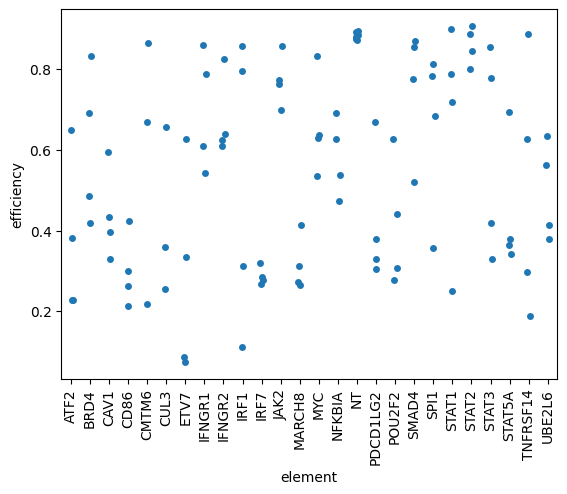

In [32]:
sns.stripplot(median_efficiency, x="element", y="efficiency")
plt.xticks(rotation=90)

In [33]:
effects_df_long = model.get_element_effects()
effects_df_long

,loc,scale,element,gene,z_value,q_value
8,-0.876393,0.031560,IFNGR2,IFNGR2,-27.768974,1.028318e-169
19,-1.344928,0.075331,STAT1,STAT1,-17.853518,2.713931e-71
4,-0.775238,0.049051,CMTM6,CMTM6,-15.804711,2.887105e-56
24,-0.781140,0.051890,UBE2L6,UBE2L6,-15.053682,3.265399e-51
6,-1.198119,0.117104,ETV7,ETV7,-10.231279,1.436095e-24
14,-1.020378,0.104340,NFKBIA,NFKBIA,-9.779382,1.380513e-22
21,-0.599849,0.065121,STAT3,STAT3,-9.211357,3.220276e-20
23,-0.960609,0.109450,TNFRSF14,TNFRSF14,-8.776657,1.684056e-18
11,-0.475334,0.061688,JAK2,JAK2,-7.705489,1.303432e-14
1,-0.786369,0.116045,BRD4,BRD4,-6.776434,1.231780e-11


In [34]:
effects_df = effects_df_long.pivot_table(values="loc", index="element", columns="gene").fillna(0)
effects_df

gene,ATF2,BRD4,CAV1,CD86,CMTM6,CUL3,ETV7,IFNGR1,IFNGR2,IRF1,...,PDCD1LG2,POU2F2,SMAD4,SPI1,STAT1,STAT2,STAT3,STAT5A,TNFRSF14,UBE2L6
element,,,,,,,,,,,,,,,,,,,,,
ATF2,-0.477455,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
BRD4,0.000000,-0.786369,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
CAV1,0.000000,0.000000,-1.187316,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
CD86,0.000000,0.000000,0.000000,-0.873075,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
CMTM6,0.000000,0.000000,0.000000,0.000000,-0.775238,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
CUL3,0.000000,0.000000,0.000000,0.000000,0.000000,-0.935444,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
ETV7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.198119,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
IFNGR1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.209066,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
IFNGR2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.876393,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000


In [35]:
cis_effects = effects_df_long.query("element==gene")
cis_effects

,loc,scale,element,gene,z_value,q_value
8,-0.876393,0.031560,IFNGR2,IFNGR2,-27.768974,1.028318e-169
19,-1.344928,0.075331,STAT1,STAT1,-17.853518,2.713931e-71
4,-0.775238,0.049051,CMTM6,CMTM6,-15.804711,2.887105e-56
24,-0.781140,0.051890,UBE2L6,UBE2L6,-15.053682,3.265399e-51
6,-1.198119,0.117104,ETV7,ETV7,-10.231279,1.436095e-24
14,-1.020378,0.104340,NFKBIA,NFKBIA,-9.779382,1.380513e-22
21,-0.599849,0.065121,STAT3,STAT3,-9.211357,3.220276e-20
23,-0.960609,0.109450,TNFRSF14,TNFRSF14,-8.776657,1.684056e-18
11,-0.475334,0.061688,JAK2,JAK2,-7.705489,1.303432e-14
1,-0.786369,0.116045,BRD4,BRD4,-6.776434,1.231780e-11


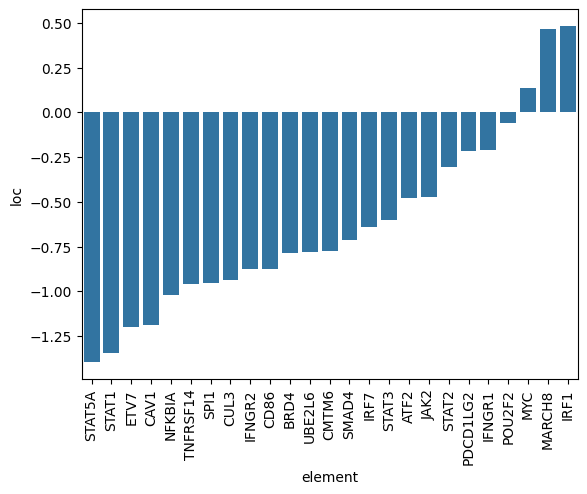

In [36]:
# median_cis_effect = guide.median()["cis_effect"].detach().cpu()
# low_cis_effect, high_cis_effect = (
    # guide.quantiles([0.159, 0.841])["cis_effect"].detach().cpu()
# )
# sigma_cis_effect = high_cis_effect - median_cis_effect
# z_score_cis_effect = median_cis_effect / sigma_cis_effect

sns.barplot(cis_effects.sort_values("loc"), x="element", y="loc")
plt.xticks(rotation=90)
plt.show()

# sns.barplot(x=elements, y=z_score_cis_effect.squeeze())

# plt.xticks(rotation=90)
# plt.show()

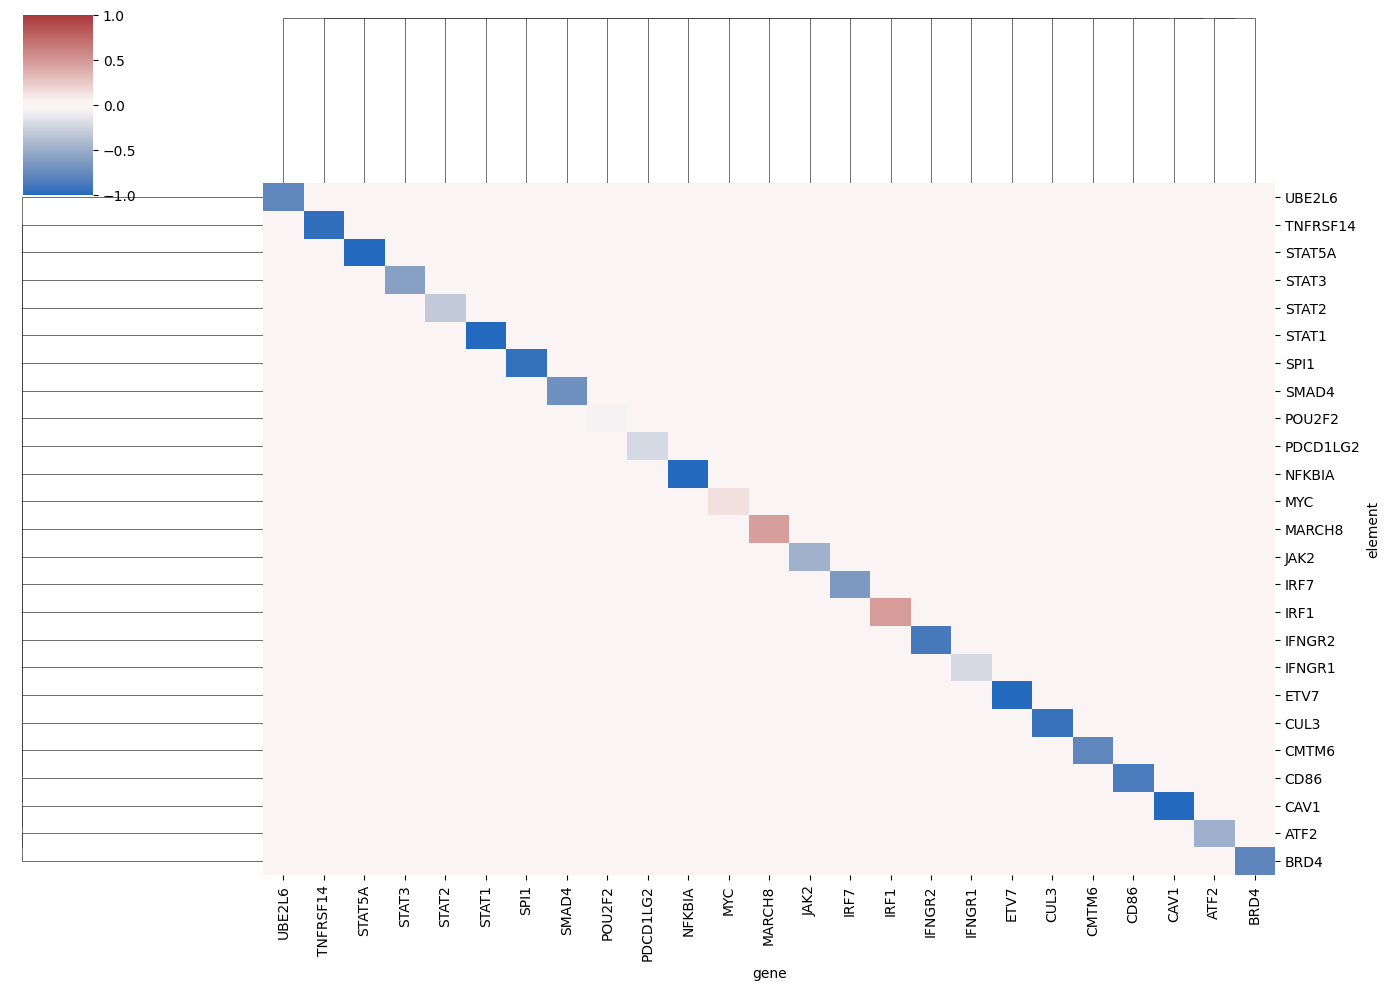

In [37]:

sns.clustermap(
    effects_df,
    center=0,
    vmax=1,
    vmin=-1,
    cmap="vlag",
    metric="cosine",
    figsize=(14, 10),
    # col_cluster=False,
    # row_cluster=False
)

element,ATF2,BRD4,CAV1,CD86,CMTM6,CUL3,ETV7,IFNGR1,IFNGR2,IRF1,...,PDCD1LG2,POU2F2,SMAD4,SPI1,STAT1,STAT2,STAT3,STAT5A,TNFRSF14,UBE2L6
0,-0.093419,-0.072805,-0.025894,0.040693,-0.034428,0.040514,-0.103027,-0.108837,-0.051662,-0.053661,...,0.021002,-0.051521,-0.004503,-0.152089,0.024115,0.048975,0.044855,0.026462,-0.037056,-0.168963
1,-0.041436,0.038886,0.051325,0.064239,-0.013742,-0.007602,-0.074355,-0.016267,-0.033530,0.051592,...,-0.001570,-0.111685,0.042921,-0.207827,0.057501,-0.028906,-0.078358,-0.035631,0.037055,-0.055576
2,0.100357,0.286408,0.017715,0.011996,-0.036966,0.183765,0.098884,-0.141620,0.076065,0.110032,...,-0.008144,-0.022564,-0.021582,-0.363053,-0.074670,0.094977,-0.144357,-0.135342,0.048737,-0.044581
3,-0.045744,-0.112622,-0.033262,-0.047834,0.024269,0.131420,-0.009511,1.752806,1.811009,0.658631,...,-0.029873,-0.060515,-0.103433,-0.020984,2.491119,0.020463,-0.065798,-0.010312,-0.009142,-0.044260
4,-0.064862,-0.140880,0.198171,-0.098434,0.095176,-0.405319,0.110151,-0.099908,-0.071145,-0.001604,...,-0.062129,-0.284338,-0.004507,0.963736,0.462021,-0.360920,-0.066728,0.094751,0.025327,0.223927
5,-0.069356,0.626389,0.336377,0.184010,0.014846,1.021803,0.132405,-0.018068,-0.181764,-0.329769,...,0.437643,0.415206,-1.272053,-0.214149,0.022917,-0.065082,0.215042,0.120727,0.205675,0.298251
6,0.070689,0.104258,0.065186,0.015800,0.049249,-0.106003,-0.068264,0.024024,0.046590,-0.037121,...,0.098206,-0.071377,-0.080305,0.040888,-0.034396,-0.022391,0.156684,0.013182,-0.180321,-0.070577
7,-0.038223,0.035359,-0.071741,-0.013756,-0.134788,-0.037761,0.152210,-0.092843,0.037736,0.063121,...,-0.014656,-0.132165,0.027922,0.102280,0.108149,0.072408,-0.185581,-0.033367,0.051379,-0.031778
8,-0.083860,-0.139046,-0.054173,0.077894,0.140064,0.080812,0.037331,-0.078034,0.041629,0.084657,...,0.049130,0.039357,-0.045813,0.204573,-0.037782,-0.053804,-0.175264,0.147398,0.077103,0.047064
9,-0.006926,1.957044,0.074854,0.071390,0.045279,0.443787,0.014193,0.016307,0.026501,-0.013162,...,0.275150,0.085494,0.300557,1.216066,-0.005071,0.045099,-0.076941,-0.034220,-0.048441,-0.221685


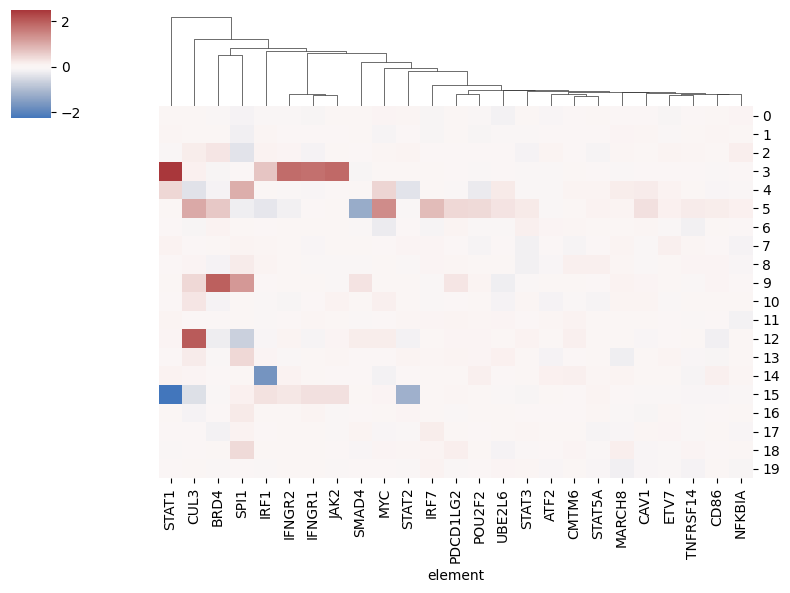

In [38]:
pert_factors = pd.DataFrame(
    model.module.guide.median()["pert_factors"].squeeze(),
    columns=elements,
)
sns.clustermap(pert_factors, cmap="vlag", figsize=(8, 6), row_cluster=False, center=0)
pert_factors



In [39]:
pert_loadings = pd.DataFrame(
    model.module.guide.median()["pert_loadings"].squeeze(),
    columns=mdata["rna"].var_names,
)

pert_loadings


gene_symbol,STAT2,CAV1,STAT1,CD86,IRF7,ATF2,STAT3,JAK2,NFKBIA,SMAD4,...,RP11-54O7.18,C1orf159,TNFRSF18,TNFRSF4,SDF4,B3GALT6,FAM132A,RP5-902P8.12,UBE2J2,SCNN1D
0,0.044092,-0.018523,0.027316,0.017589,0.034867,0.026683,-0.076966,-0.065083,-0.102449,0.010691,...,-0.033784,-0.075337,0.000100,-0.049887,-0.055368,-0.036251,0.012189,-0.000992,-0.005616,-0.008471
1,0.006083,-0.014926,0.027432,0.031594,0.017746,0.023535,0.003195,-0.014050,0.033312,0.058141,...,-0.033633,-0.001746,0.041990,0.001854,-0.001132,-0.022313,0.012834,-0.004911,-0.060430,0.007785
2,-0.020986,-0.001380,0.104322,-0.055179,-0.037135,0.000956,-0.000329,0.005526,0.085019,0.057058,...,-0.019025,-0.092499,-0.002450,-0.088856,0.004478,-0.002540,-0.126462,-0.025582,-0.060399,0.006029
3,-0.409149,-0.182281,-0.568659,0.009661,-0.503784,0.088622,-0.214326,-0.926241,0.253956,0.048928,...,0.224412,-0.080711,-0.056433,0.058071,0.044288,0.093025,0.093748,-0.019980,0.096074,0.016817
4,0.114419,-0.010777,0.016946,-0.061501,-0.024678,-0.045273,0.135709,0.003431,-0.086844,-0.075761,...,0.104313,0.048363,0.038308,0.044867,0.000991,0.055253,-0.035214,-0.033632,-0.021243,0.009835
5,0.035227,-0.056695,-0.118347,-0.079318,-0.080966,-0.090622,-0.096476,0.061059,-0.154157,-0.042308,...,-0.285213,-0.017909,-0.051339,-0.868174,-0.088698,-0.194439,0.009052,-0.008997,-0.097723,0.002685
6,0.020203,-0.050308,-0.018524,0.005651,0.016671,0.027106,-0.042581,-0.027549,0.028458,0.016549,...,0.042192,0.011454,0.013464,0.006225,-0.046317,0.074454,0.058989,0.013128,-0.043942,0.060916
7,0.024198,0.020184,-0.008906,-0.012625,0.036867,0.058518,0.030899,0.025160,0.068770,0.020255,...,-0.017247,-0.034028,-0.008871,0.006422,-0.052334,0.022288,-0.012310,0.068640,0.022175,0.001043
8,-0.006299,0.051067,-0.043625,-0.064697,-0.005229,0.005600,0.035922,-0.012106,-0.022608,-0.066766,...,-0.051342,-0.011492,-0.048639,-0.032835,-0.107758,-0.028533,0.027967,-0.000079,-0.014868,-0.034014
9,-0.037028,-0.011259,0.064433,-0.496443,-0.228093,-0.057495,-0.019260,-0.000310,0.338317,0.121819,...,-0.030472,-0.081886,-0.027526,-0.097513,0.009649,-0.025203,-0.133539,-0.005090,-0.086980,0.026982


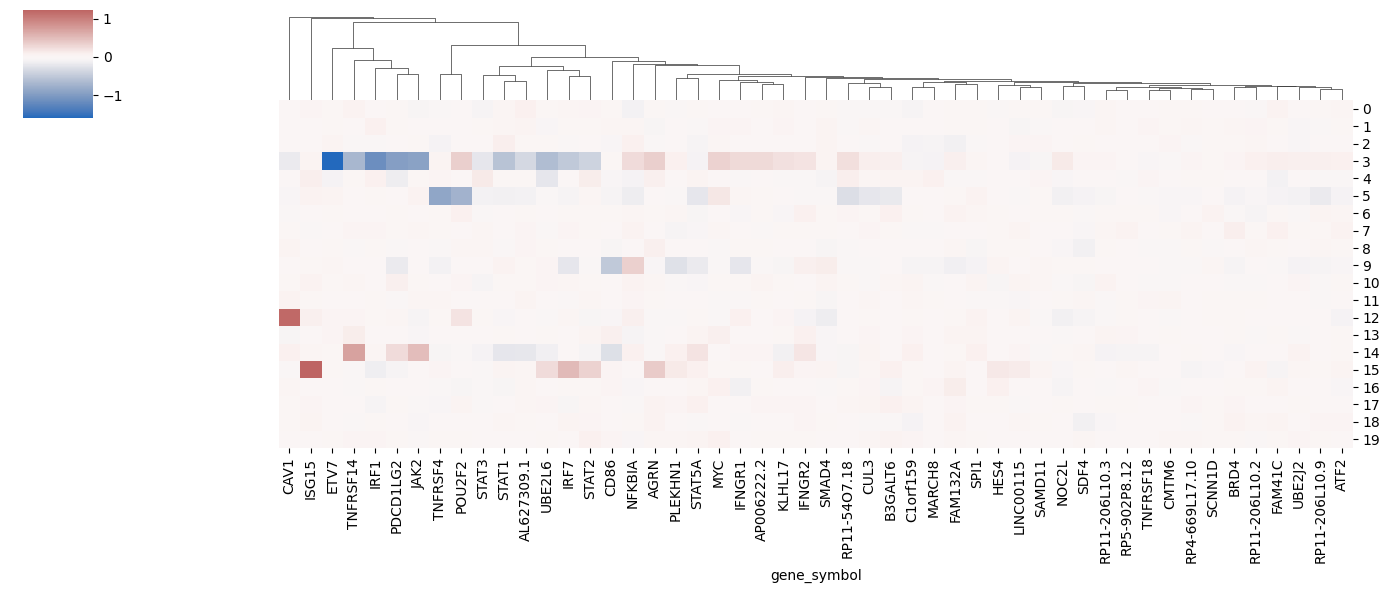

In [40]:
top_genes = (pert_loadings**2).max().nlargest(100).index
pert_loadings_subset = pert_loadings.loc[:, top_genes]
sns.clustermap(pert_loadings_subset, cmap="vlag", row_cluster=False, figsize=(14, 6), center=0)


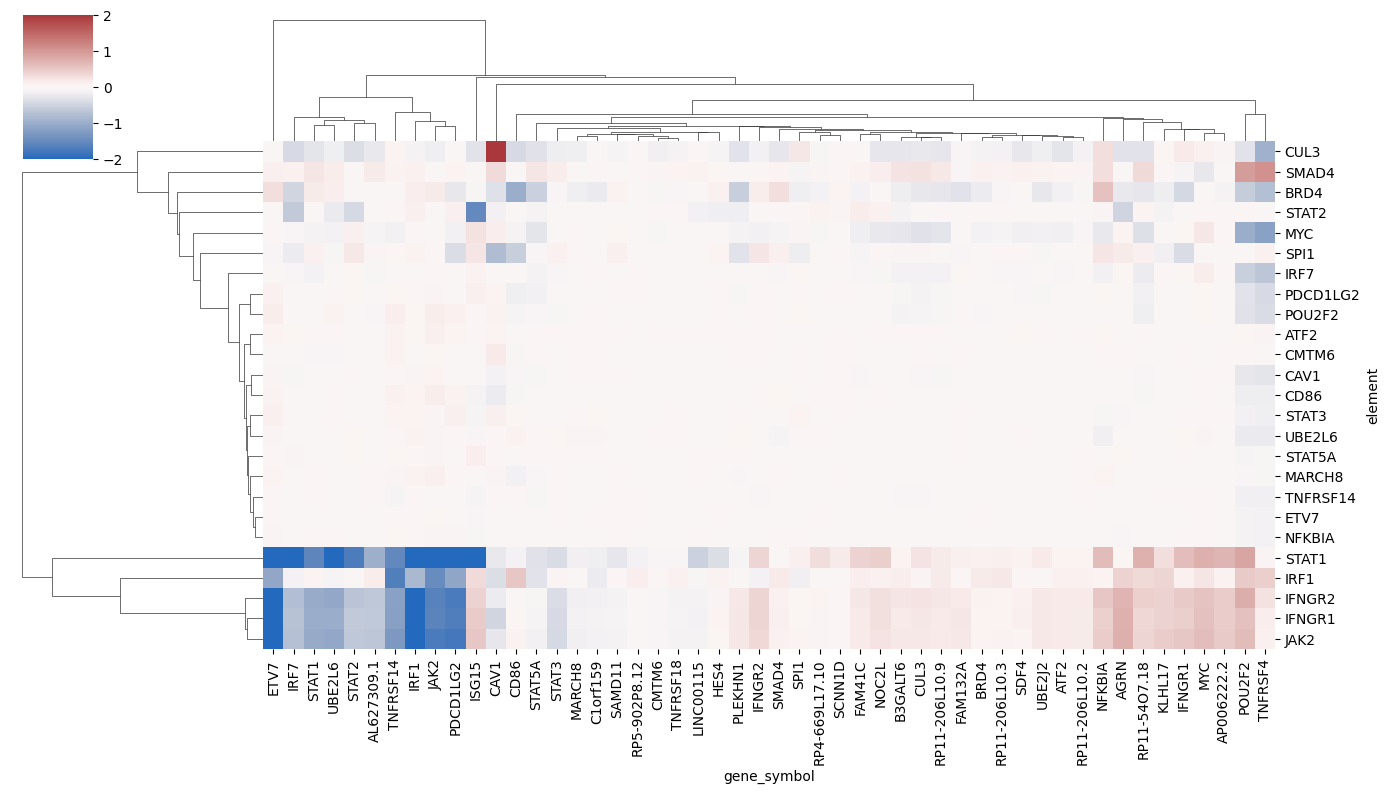

In [41]:
reconstructed_effects = pd.DataFrame(
    pert_factors.values.T @ pert_loadings.values,
    index=elements,
    columns=mdata["rna"].var_names,
)
sns.clustermap(reconstructed_effects, center=0, cmap="vlag", figsize=(14, 8),vmin=-2, vmax=2)

In [42]:
# effects_df = effects
# sns.stripplot(guide.median()["effect"])
# # print(n_guides)
# from numpy import median

# median_effect = guide.median()["trans_effect"].detach().cpu()
# low_effect, high_effect = guide.quantiles([0.159, 0.841])["trans_effect"].detach().cpu()
# sigma_effect = high_effect - low_effect
# z_score_effect = median_effect / sigma_effect

# effects_df = pd.DataFrame(
#     effects,
#     # z_score_effect,
#     columns=adata_subset.var_names,
#     index=elements,
# )
# effects_df

# effects_df = pd.DataFrame(
#     median_effect,
#     columns=adata_subset.var_names,
#     index=list(element_mapping.keys())[:n_elements],
# )
# effects_df

In [43]:

plot_genes = [g for g in list(cis_effects["element"]) if g != "control"]
plot_genes

['IFNGR2',
 'STAT1',
 'CMTM6',
 'UBE2L6',
 'ETV7',
 'NFKBIA',
 'STAT3',
 'TNFRSF14',
 'JAK2',
 'BRD4',
 'STAT2',
 'SMAD4',
 'IRF7',
 'IFNGR1',
 'SPI1',
 'STAT5A',
 'CUL3',
 'ATF2',
 'CD86',
 'CAV1',
 'PDCD1LG2',
 'POU2F2',
 'MYC',
 'MARCH8',
 'IRF1']

In [44]:
# effect_variance = effects_df.var(axis=0)
effect_variance = effects_df_long.groupby("gene")["loc"].var()
# effect_variance = (effects_df.abs() > 5).sum(axis=0)
# effect_variance = (effects_df.loc[["STAT3", "STAT5A", "CAV1", "CD86"]].abs()).sum(
#     axis=0
# )
hvgs = effect_variance.nlargest(50).index.tolist()
hvgs
# effects_df[effects_df["gene"].isin(hvgs)]


['ATF2',
 'BRD4',
 'CAV1',
 'CD86',
 'CMTM6',
 'CUL3',
 'ETV7',
 'IFNGR1',
 'IFNGR2',
 'IRF1',
 'IRF7',
 'JAK2',
 'MARCH8',
 'MYC',
 'NFKBIA',
 'PDCD1LG2',
 'POU2F2',
 'SMAD4',
 'SPI1',
 'STAT1',
 'STAT2',
 'STAT3',
 'STAT5A',
 'TNFRSF14',
 'UBE2L6']

In [45]:
# plt.scatter(guide.median()["gene_mean"].cpu().log(), guide.median()["dispersion"].cpu().log(), alpha=0.1)

In [46]:
if not smoke_test:
    pyro.get_param_store().save("params.save")

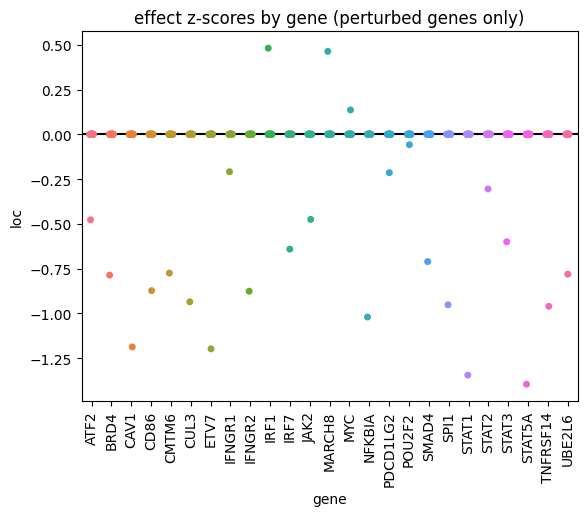

In [47]:
n_plot_genes = 25
sns.stripplot(effects_df.iloc[:, :n_plot_genes])
# sns.stripplot(effects_df[[g for g in plot_genes if g in effects_df.columns]])
#
plt.axhline(0, color="black")
plt.xticks(rotation=90)
plt.ylabel("loc")
plt.title("effect z-scores by gene (perturbed genes only)")
plt.show()

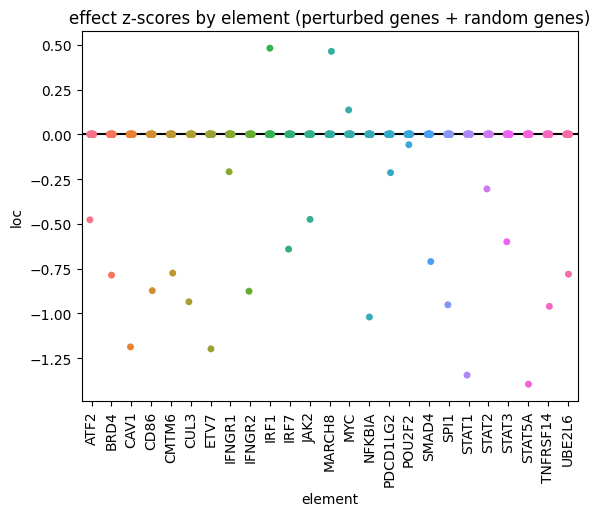

In [48]:
sns.stripplot(effects_df.T, alpha=1)
plt.xticks(rotation=90)
plt.axhline(0, color="black")
plt.ylabel("loc")
plt.xlabel("element")
plt.title("effect z-scores by element (perturbed genes + random genes)")
plt.show()

In [49]:
effects_df.T["CMTM6"].sort_values()

gene
CMTM6      -0.775238
ATF2        0.000000
STAT5A      0.000000
STAT3       0.000000
STAT2       0.000000
STAT1       0.000000
SPI1        0.000000
SMAD4       0.000000
POU2F2      0.000000
PDCD1LG2    0.000000
NFKBIA      0.000000
MYC         0.000000
MARCH8      0.000000
JAK2        0.000000
IRF7        0.000000
IRF1        0.000000
IFNGR2      0.000000
IFNGR1      0.000000
ETV7        0.000000
CUL3        0.000000
CD86        0.000000
CAV1        0.000000
BRD4        0.000000
TNFRSF14    0.000000
UBE2L6      0.000000
Name: CMTM6, dtype: float32